In [1]:
import pandas as pd
import numpy as np
import scipy as sp
import scipy.spatial.distance as spd
import importlib

import plotly.express as px
import matplotlib.pyplot as plt

import utility_functions as uf

In [303]:
year = 2023
cap_prob = 0.03
cap_articles = 500
mode_list = ["individual", "collaborative"]

In [364]:
df_cs_indiv = pd.read_csv(uf.PATH+"df_country_subfield/individual_{}.csv".format(year), index_col=0)
df_cs_collab = pd.read_csv(uf.PATH+"df_country_subfield/collaborative_{}.csv".format(year), index_col=0)

df_prob_indiv = df_cs_indiv.div(df_cs_indiv.sum(axis=1), axis=0)
df_prob_collab = df_cs_collab.div(df_cs_collab.sum(axis=1), axis=0)

df_prob_capped_indiv = uf.df_capped(df_prob_indiv, cap_prob, year)
df_prob_capped_collab = uf.df_capped(df_prob_collab, cap_prob, year)

# country_idx = df_cs_indiv.sum(axis=1).to_frame("total").query("total > @cap_articles").index.intersection(
#     df_cs_collab.sum(axis=1).to_frame("total").query("total > @cap_articles").index
# )

df_country_stats = pd.read_csv(uf.PATH+f"df_stats_country_yearly.csv", index_col=0)

In [365]:
df_country_stats

,mode,year,entropy,norm_entropy,total_articles,log_total_articles,gini
country,,,,,,,
AE,individual,1970,2.740875,0.496045,34.0,3.526361,0.323529
AF,individual,1970,1.609438,0.291277,5.0,1.609438,0.000000
AM,individual,1970,3.126757,0.565882,65.0,4.174387,0.383333
AO,individual,1970,0.693147,0.125446,2.0,0.693147,0.000000
AR,individual,1970,4.278805,0.774381,873.0,6.771936,0.600798
...,...,...,...,...,...,...,...
WS,collaborative,2022,2.770960,0.501129,44.0,3.784190,0.371901
YE,collaborative,2022,4.587269,0.829610,1165.0,7.060476,0.560279
ZA,collaborative,2022,4.710430,0.851884,12326.0,9.419466,0.636341


In [366]:
df_cs_indiv

,1100,1102,1103,1104,1105,1106,1107,1108,1109,1110,...,3603,3604,3605,3607,3608,3609,3611,3612,3614,3616
country,,,,,,,,,,,,,,,,,,,,,
AD,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AE,3.0,2.0,1.0,3.0,3.0,26.0,NaN,NaN,2.0,56.0,...,3.0,9.0,22.0,2.0,NaN,3.0,8.0,5.0,11.0,6.0
AF,1.0,5.0,3.0,2.0,1.0,1.0,NaN,NaN,NaN,15.0,...,NaN,NaN,2.0,NaN,NaN,2.0,NaN,3.0,NaN,1.0
AG,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,2.0,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN
AL,10.0,1.0,NaN,2.0,7.0,2.0,1.0,NaN,7.0,6.0,...,NaN,2.0,2.0,NaN,NaN,NaN,2.0,1.0,2.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
WS,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
YE,NaN,NaN,NaN,1.0,4.0,8.0,NaN,NaN,2.0,14.0,...,1.0,8.0,6.0,1.0,NaN,NaN,NaN,NaN,4.0,2.0
ZA,67.0,73.0,49.0,22.0,157.0,156.0,22.0,NaN,86.0,459.0,...,4.0,38.0,22.0,5.0,NaN,33.0,21.0,12.0,55.0,47.0


In [367]:
n_years = 5

df_cs_indiv_roll = (
    df_cs_indiv
    .sort_index()
    .groupby(level=0)
    .fillna(0)
    .rolling(n_years).sum()
    .replace({0: np.nan})
    .dropna(how="all")
    # .reset_index(level=0, drop=True)
)
display(df_cs_indiv_roll)
df_prob_indiv_roll = df_cs_indiv_roll.div(df_cs_indiv_roll.sum(axis=1), axis=0)


df_cs_collab_roll = (
    df_cs_collab
    .sort_index()
    .groupby(level=0)
    .fillna(0)
    .rolling(n_years).sum()
    .replace({0: np.nan})
    .dropna(how="all")
    # .reset_index(level=0, drop=True)
)
df_prob_collab_roll = df_cs_collab_roll.div(df_cs_collab_roll.sum(axis=1), axis=0)

/var/folders/kq/3vlmcmh917x4z481rl4yj6t00000gn/T/ipykernel_12342/603725177.py:4: FutureWarning:

DataFrameGroupBy.fillna is deprecated and will be removed in a future version. Use obj.ffill() or obj.bfill() for forward or backward filling instead. If you want to fill with a single value, use DataFrame.fillna instead



,1100,1102,1103,1104,1105,1106,1107,1108,1109,1110,...,3603,3604,3605,3607,3608,3609,3611,3612,3614,3616
country,,,,,,,,,,,,,,,,,,,,,
AL,14.0,8.0,4.0,7.0,11.0,29.0,1.0,NaN,9.0,77.0,...,3.0,13.0,26.0,2.0,NaN,6.0,10.0,9.0,13.0,7.0
AM,24.0,15.0,7.0,10.0,19.0,51.0,1.0,NaN,12.0,96.0,...,3.0,13.0,26.0,2.0,NaN,6.0,10.0,14.0,13.0,8.0
AO,21.0,13.0,6.0,7.0,16.0,25.0,3.0,NaN,10.0,42.0,...,NaN,4.0,5.0,1.0,NaN,6.0,2.0,9.0,2.0,2.0
AR,153.0,64.0,30.0,25.0,273.0,229.0,18.0,NaN,111.0,373.0,...,1.0,13.0,12.0,2.0,NaN,25.0,17.0,10.0,7.0,25.0
AS,153.0,64.0,30.0,25.0,273.0,229.0,18.0,NaN,111.0,373.0,...,1.0,11.0,12.0,2.0,NaN,24.0,17.0,10.0,7.0,25.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
WS,15.0,14.0,28.0,49.0,47.0,108.0,1.0,1.0,26.0,232.0,...,1.0,6.0,9.0,1.0,NaN,3.0,1.0,22.0,21.0,15.0
YE,15.0,14.0,28.0,50.0,51.0,116.0,1.0,1.0,28.0,246.0,...,2.0,14.0,15.0,2.0,NaN,3.0,1.0,22.0,25.0,17.0
ZA,82.0,87.0,77.0,72.0,208.0,272.0,23.0,1.0,114.0,705.0,...,6.0,52.0,37.0,7.0,NaN,36.0,22.0,34.0,80.0,64.0


/var/folders/kq/3vlmcmh917x4z481rl4yj6t00000gn/T/ipykernel_12342/603725177.py:18: FutureWarning:

DataFrameGroupBy.fillna is deprecated and will be removed in a future version. Use obj.ffill() or obj.bfill() for forward or backward filling instead. If you want to fill with a single value, use DataFrame.fillna instead



In [368]:
df_cs_indiv_roll

,1100,1102,1103,1104,1105,1106,1107,1108,1109,1110,...,3603,3604,3605,3607,3608,3609,3611,3612,3614,3616
country,,,,,,,,,,,,,,,,,,,,,
AL,14.0,8.0,4.0,7.0,11.0,29.0,1.0,NaN,9.0,77.0,...,3.0,13.0,26.0,2.0,NaN,6.0,10.0,9.0,13.0,7.0
AM,24.0,15.0,7.0,10.0,19.0,51.0,1.0,NaN,12.0,96.0,...,3.0,13.0,26.0,2.0,NaN,6.0,10.0,14.0,13.0,8.0
AO,21.0,13.0,6.0,7.0,16.0,25.0,3.0,NaN,10.0,42.0,...,NaN,4.0,5.0,1.0,NaN,6.0,2.0,9.0,2.0,2.0
AR,153.0,64.0,30.0,25.0,273.0,229.0,18.0,NaN,111.0,373.0,...,1.0,13.0,12.0,2.0,NaN,25.0,17.0,10.0,7.0,25.0
AS,153.0,64.0,30.0,25.0,273.0,229.0,18.0,NaN,111.0,373.0,...,1.0,11.0,12.0,2.0,NaN,24.0,17.0,10.0,7.0,25.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
WS,15.0,14.0,28.0,49.0,47.0,108.0,1.0,1.0,26.0,232.0,...,1.0,6.0,9.0,1.0,NaN,3.0,1.0,22.0,21.0,15.0
YE,15.0,14.0,28.0,50.0,51.0,116.0,1.0,1.0,28.0,246.0,...,2.0,14.0,15.0,2.0,NaN,3.0,1.0,22.0,25.0,17.0
ZA,82.0,87.0,77.0,72.0,208.0,272.0,23.0,1.0,114.0,705.0,...,6.0,52.0,37.0,7.0,NaN,36.0,22.0,34.0,80.0,64.0


In [370]:
df_stats = (
    pd.DataFrame(index=(df_cs_indiv.index.union(df_cs_collab.index)))
    .merge(uf.df_country[["alpha-2", "alpha-3", "name", "sub-region", "region"]], left_index=True, right_on="alpha-2")
    .rename(columns={"alpha-2": "country"})
    .set_index("country")
    .assign(
        total_indiv=df_cs_indiv.sum(axis=1),
        total_collab=df_cs_collab.sum(axis=1),
        log_total_indiv=lambda df: np.log(df.total_indiv),
        log_total_collab=lambda df: np.log(df.total_collab),
        gini_indiv= df_cs_indiv.apply(uf.gini, axis=1),
        gini_collab=df_cs_collab.apply(uf.gini, axis=1),
    )
)
df_stats

,alpha-3,name,sub-region,region,total_indiv,total_collab,log_total_indiv,log_total_collab,gini_indiv,gini_collab
country,,,,,,,,,,
AD,AND,Andorra,Southern Europe,Europe,8.0,26.0,2.079442,3.258097,0.166667,0.256410
AE,ARE,United Arab Emirates,Western Asia,Asia,5170.0,9863.0,8.550628,9.196546,0.626830,0.662031
AF,AFG,Afghanistan,Southern Asia,Asia,529.0,400.0,6.270988,5.991465,0.593240,0.477792
AG,ATG,Antigua and Barbuda,Latin America and the Caribbean,Americas,115.0,370.0,4.744932,5.913503,0.382609,0.525070
AL,ALB,Albania,Southern Europe,Europe,969.0,425.0,6.876265,6.052089,0.579670,0.449356
...,...,...,...,...,...,...,...,...,...,...
WS,WSM,Samoa,Polynesia,Oceania,12.0,34.0,2.484907,3.526361,0.203704,0.294118
YE,YEM,Yemen,Western Asia,Asia,949.0,1318.0,6.855409,7.183871,0.543132,0.561695
ZA,ZAF,South Africa,Sub-Saharan Africa,Africa,19694.0,12556.0,9.888069,9.437954,0.646743,0.631085


In [ ]:
df_stats_roll = (
    pd.DataFrame(index=(df_cs_indiv_roll.index.union(df_cs_collab.index)))
    .merge(uf.df_country[["alpha-2", "alpha-3", "name", "sub-region", "region"]], left_index=True, right_on="alpha-2")
    .rename(columns={"alpha-2": "country"})
    .set_index("country")
    .assign(
        total_indiv=df_cs_indiv_roll.sum(axis=1),
        total_collab=df_cs_collab_roll.sum(axis=1),
        log_total_indiv=lambda df: np.log(df.total_indiv),
        log_total_collab=lambda df: np.log(df.total_collab),
        gini_indiv= df_cs_indiv_roll.apply(uf.gini, axis=1),
        gini_collab=df_cs_collab_roll.apply(uf.gini, axis=1),
    )
)

,alpha-3,name,sub-region,region,total_indiv,total_collab,log_total_indiv,log_total_collab,gini_indiv,gini_collab
country,,,,,,,,,,
AD,AND,Andorra,Southern Europe,Europe,8.0,26.0,2.079442,3.258097,0.166667,0.256410
AE,ARE,United Arab Emirates,Western Asia,Asia,5170.0,9863.0,8.550628,9.196546,0.626830,0.662031
AF,AFG,Afghanistan,Southern Asia,Asia,529.0,400.0,6.270988,5.991465,0.593240,0.477792
AG,ATG,Antigua and Barbuda,Latin America and the Caribbean,Americas,115.0,370.0,4.744932,5.913503,0.382609,0.525070
AL,ALB,Albania,Southern Europe,Europe,969.0,425.0,6.876265,6.052089,0.579670,0.449356
...,...,...,...,...,...,...,...,...,...,...
WS,WSM,Samoa,Polynesia,Oceania,12.0,34.0,2.484907,3.526361,0.203704,0.294118
YE,YEM,Yemen,Western Asia,Asia,949.0,1318.0,6.855409,7.183871,0.543132,0.561695
ZA,ZAF,South Africa,Sub-Saharan Africa,Africa,19694.0,12556.0,9.888069,9.437954,0.646743,0.631085


In [372]:
df_stats

,alpha-3,name,sub-region,region,total_indiv,total_collab,log_total_indiv,log_total_collab,gini_indiv,gini_collab
country,,,,,,,,,,
AD,AND,Andorra,Southern Europe,Europe,8.0,26.0,2.079442,3.258097,0.166667,0.256410
AE,ARE,United Arab Emirates,Western Asia,Asia,5170.0,9863.0,8.550628,9.196546,0.626830,0.662031
AF,AFG,Afghanistan,Southern Asia,Asia,529.0,400.0,6.270988,5.991465,0.593240,0.477792
AG,ATG,Antigua and Barbuda,Latin America and the Caribbean,Americas,115.0,370.0,4.744932,5.913503,0.382609,0.525070
AL,ALB,Albania,Southern Europe,Europe,969.0,425.0,6.876265,6.052089,0.579670,0.449356
...,...,...,...,...,...,...,...,...,...,...
WS,WSM,Samoa,Polynesia,Oceania,12.0,34.0,2.484907,3.526361,0.203704,0.294118
YE,YEM,Yemen,Western Asia,Asia,949.0,1318.0,6.855409,7.183871,0.543132,0.561695
ZA,ZAF,South Africa,Sub-Saharan Africa,Africa,19694.0,12556.0,9.888069,9.437954,0.646743,0.631085


In [174]:
px.scatter(df_stats.query("total_indiv > 500"), x="gini_indiv", y="gini_collab", hover_data=["name"])

In [175]:
uf.get_subfield_info(2730)

,subfield_id,subfield_name,field_name,domain_name
157,2730,Oncology,Medicine,Health Sciences


In [176]:
uf.df_topics[["subfield_id", "subfield_name", "field_id", "field_name", "domain_id", "domain_name"]].drop_duplicates()

,subfield_id,subfield_name,field_id,field_name,domain_id,domain_name
0,1908,Geophysics,19,Earth and Planetary Sciences,3,Physical Sciences
1,3107,"Atomic and Molecular Physics, and Optics",31,Physics and Astronomy,3,Physical Sciences
2,1408,Strategy and Management,14,"Business, Management and Accounting",2,Social Sciences
3,1111,Soil Science,11,Agricultural and Biological Sciences,1,Life Sciences
4,2309,Nature and Landscape Conservation,23,Environmental Science,3,Physical Sciences
...,...,...,...,...,...,...
4129,2702,Anatomy,27,Medicine,4,Health Sciences
4322,2104,Nuclear Energy and Engineering,21,Energy,3,Physical Sciences
4422,2103,Fuel Technology,21,Energy,3,Physical Sciences
4440,2200,General Engineering,22,Engineering,3,Physical Sciences


In [177]:
country = "US"
df_profile_country = pd.concat([
    df_prob_indiv.loc[country].to_frame("indiv"), df_prob_collab.loc[country].to_frame("collab")
])
px.bar(df_profile_country, x=df_profile_country.index, y=["indiv", "collab"], barmode="overlay",
       title=f"National (individual) vs International (collaborative) profiles: {uf.id2name_country[country]}, {year}")

# Jaccard dissimilarity

$$
Jaccard(A, B) = 1 - \dfrac{|A \cap B|}{|A \cup B|}
$$

In [178]:
country = "ID"
eps = 0

In [179]:
for c in df_stats.index:
    if (c in df_cs_collab.index) and (c in df_cs_indiv.index):
        # print(c)
        df_stats.loc[c, "jaccard"] = spd.jaccard(df_cs_collab_roll.loc[c] > eps, df_cs_indiv_roll.loc[c] > eps)
    else:
        df_stats.loc[c, "jaccard"] = 1

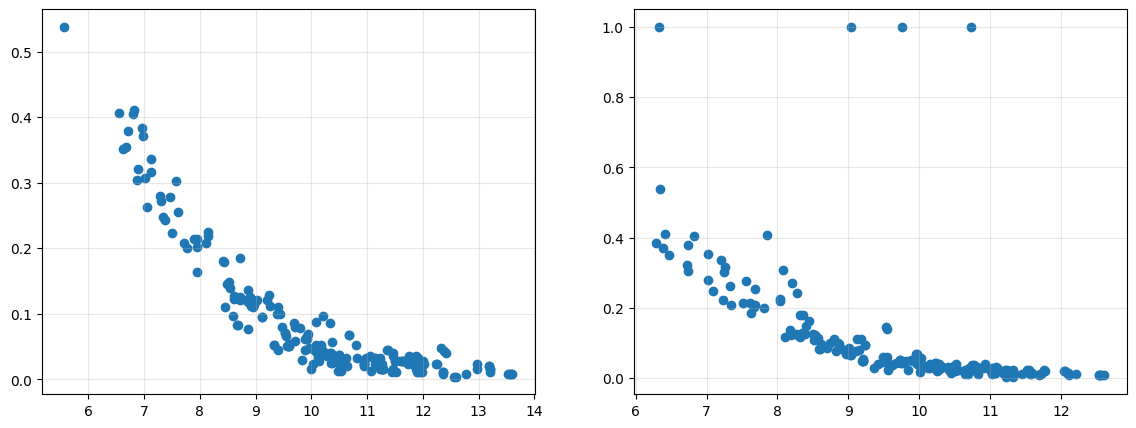

In [180]:
fig, (ax1, ax2) = plt.subplots(nrows = 1, ncols=2, figsize=(14, 5))

ax1.scatter(df_stats.log_total_indiv, df_stats.jaccard)
ax1.grid(alpha=0.3)

ax2.scatter(df_stats.log_total_collab, df_stats.jaccard)
ax2.grid(alpha=0.3)


In [181]:
# px.scatter(df_stats, x=["log_total_collab", "log_total_indiv"], y="jaccard", hover_data=["name", "region"], title="Jaccard vs N_articles")
# px.scatter(df_stats, x=["gini_collab", "gini_indiv"], y="jaccard", hover_data=["name", "region"], title="Jaccard vs N_articles")

In [182]:
# px.scatter(df_stats, x=["gini_collab", "gini_indiv"], y="jaccard", hover_data=["name", "region"], title="Jaccard vs N_articles")

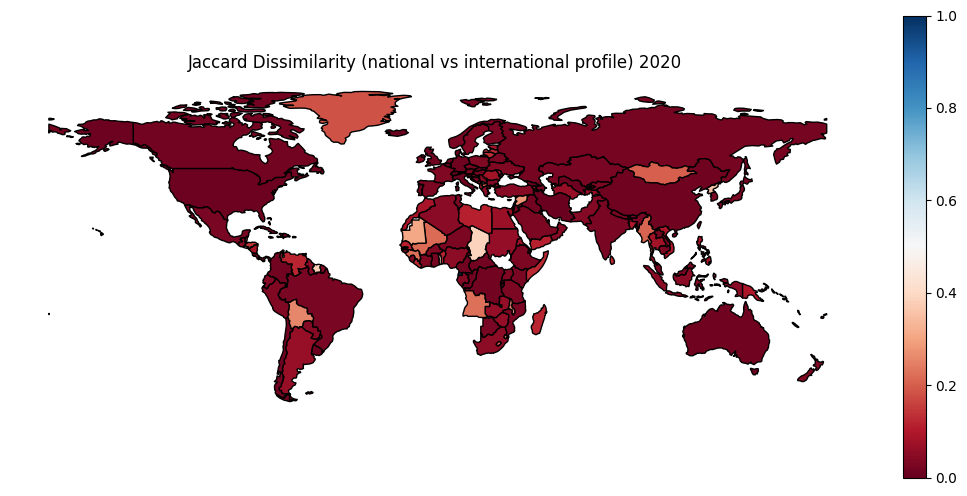

In [183]:
_, _ = uf.plot_map_continuous(df_stats, "jaccard", range=(0, 1), title=f"Jaccard Dissimilarity (national vs international profile) {year}")

In [184]:
def jaccard_turn(a, b):
    intersect = a == b
    outer_a = a[~intersect].sum()
    outer_b = b[~intersect].sum()
    return 2 * min(outer_a, outer_b) / (a[intersect].sum() + 2 * min(outer_a, outer_b))

In [185]:
for c in df_stats.index:
    if (c in df_cs_collab.index) and (c in df_cs_indiv.index):
        # print(c)
        df_stats.loc[c, "jaccard_turn"] = jaccard_turn(df_cs_collab_roll.loc[c] > eps, df_cs_indiv_roll.loc[c] > eps)
    else:
        df_stats.loc[c, "jaccard_turn"] = 1

In [186]:
px.scatter(df_stats, x=["log_total_indiv", "log_total_collab"], y="jaccard_turn", hover_data=["name", "region"], title="Jaccard Turn vs N_articles")

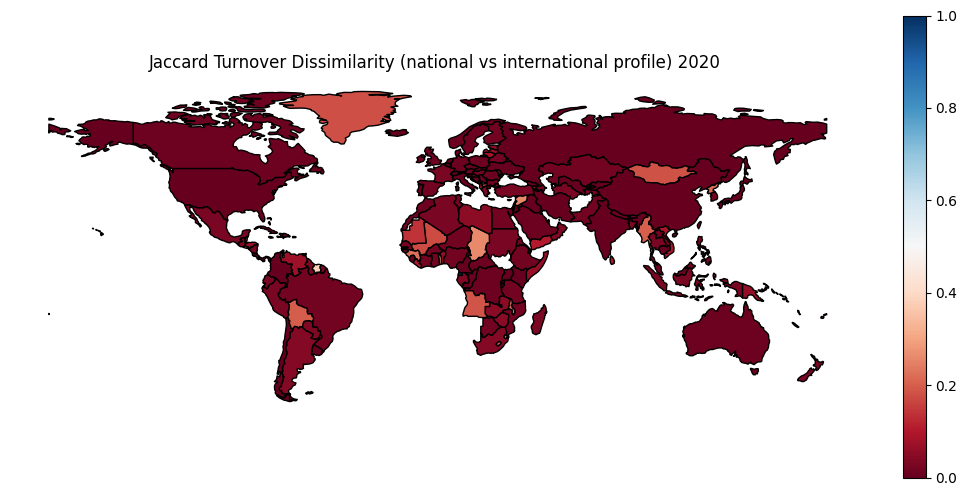

In [187]:
_, _ = uf.plot_map_continuous(df_stats, "jaccard_turn", range=(0, 1), title=f"Jaccard Turnover Dissimilarity (national vs international profile) {year}")

# Bray-Curtis



In [188]:
for c in df_stats.index:
    if (c in df_cs_collab.index) and (c in df_cs_indiv.index):
        # print(c)
        df_stats.loc[c, "bray_curtis"] = spd.braycurtis(df_cs_collab_roll.loc[c] > 0, df_cs_indiv_roll.loc[c] > 0)
    else:
        df_stats.loc[c, "bray_curtis"] = 1

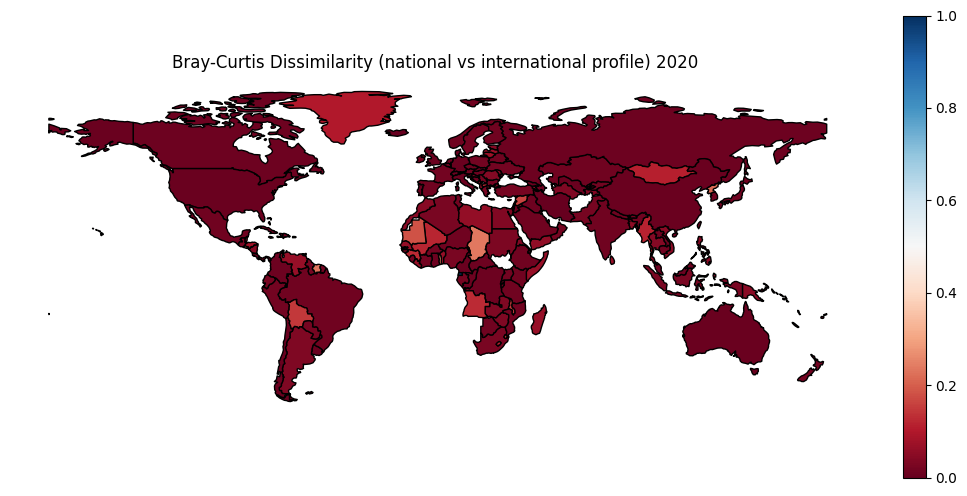

In [189]:
_, _ = uf.plot_map_continuous(df_stats, "bray_curtis", range=(0, 1), title=f"Bray-Curtis Dissimilarity (national vs international profile) {year}")

# Wasserstein-tree (probability)

In [190]:
w1_max = (
    uf.df_topics
    .sample(2)
)

subfield_tree = uf.get_subfield_tree(uf.df_topics)

# different subfield, fields, domains (maximum distance)
subfield1 = "2713"
subfield2 = "1904"
_, _, w1_max = uf.get_dist_w1_tree(subfield_tree, {subfield1: 1}, {subfield2: 1})

In [191]:
country = "US"

In [192]:
_, _, w1_dist = uf.get_dist_w1_tree(subfield_tree, df_prob_collab_roll.loc[country].dropna().to_dict(), df_prob_indiv_roll.loc[country].dropna().to_dict())

In [193]:
cap = 0.03
subfield1 = "2713"
subfield2 = "1904"

labels = df_prob_indiv.columns.astype(str)
values = (1 - cap) / len(labels) * np.ones(len(labels))

dict1 = dict(zip(labels, values))
dict2 = dict(zip(labels, values))
dict1[subfield1] = cap
dict2[subfield2] = cap
_, _, w1_max_capped = uf.get_dist_w1_tree(subfield_tree, dict1, dict2)

# df_dist_capped = uf.get_w1_distances(subfield_tree, df_prob_capped, w1_max)
# np.fill_diagonal(df_dist_capped.values, np.nan)

In [374]:
for c in df_stats.index:
    if (c in df_cs_collab.index) and (c in df_cs_indiv.index):
        # print(c)
        _, _, df_stats.loc[c, "w1_tree"] = (uf.get_dist_w1_tree(subfield_tree, df_prob_collab.loc[c].dropna().to_dict(), df_prob_indiv.loc[c].dropna().to_dict())
                                            / w1_max)
        if c not in df_cs_collab_roll.index:
            continue
        _, _, df_stats_roll.loc[c, "w1_tree"] = (uf.get_dist_w1_tree(subfield_tree, df_prob_collab_roll.loc[c].dropna().to_dict(), df_prob_indiv_roll.loc[c].dropna().to_dict())
                                            / w1_max)
        # _, _, df_stats.loc[c, "w1_tree_capped"] = (uf.get_dist_w1_tree(subfield_tree, df_prob_capped_collab.loc[c].dropna().to_dict(), df_prob_capped_indiv.loc[c].dropna().to_dict())
        #                                     )
    else:
        df_stats.loc[c, "w1_tree"] = np.nan
        df_stats.loc[c, "w1_tree_capped"] = np.nan
df_stats.w1_tree_capped = df_stats.w1_tree_capped / df_stats.w1_tree_capped.max()

In [312]:
df_stats.query("total_indiv >= @cap_articles")[["total_indiv", "total_collab", "gini_indiv", "gini_collab", "w1_tree", "w1_tree_capped"]].corr()

,total_indiv,total_collab,gini_indiv,gini_collab,w1_tree,w1_tree_capped
total_indiv,1.000000,0.867978,0.341002,0.320626,-0.251316,0.036977
total_collab,0.867978,1.000000,0.220232,0.354373,-0.235664,-0.014114
gini_indiv,0.341002,0.220232,1.000000,0.487639,0.099733,0.162679
gini_collab,0.320626,0.354373,0.487639,1.000000,-0.202910,-0.054355
w1_tree,-0.251316,-0.235664,0.099733,-0.202910,1.000000,0.108767
w1_tree_capped,0.036977,-0.014114,0.162679,-0.054355,0.108767,1.000000


In [313]:
df_stats[["total_indiv", "total_collab", "gini_indiv", "gini_collab", "w1_tree", "w1_tree_capped"]].corr()

,total_indiv,total_collab,gini_indiv,gini_collab,w1_tree,w1_tree_capped
total_indiv,1.000000,0.873944,0.230938,0.245067,-0.176145,-0.010494
total_collab,0.873944,1.000000,0.266729,0.310846,-0.202046,-0.073055
gini_indiv,0.230938,0.266729,1.000000,0.800881,-0.465380,-0.186044
gini_collab,0.245067,0.310846,0.800881,1.000000,-0.536178,-0.215923
w1_tree,-0.176145,-0.202046,-0.465380,-0.536178,1.000000,0.250874
w1_tree_capped,-0.010494,-0.073055,-0.186044,-0.215923,0.250874,1.000000


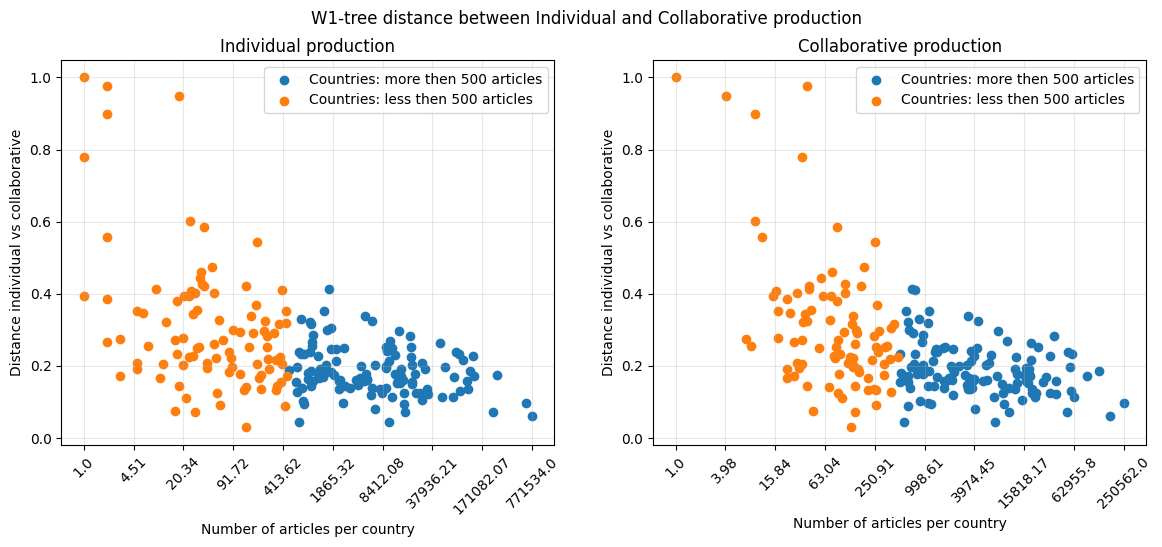

In [314]:
fig, (ax1, ax2) = plt.subplots(nrows = 1, ncols=2, figsize=(14, 5))

ax1.scatter(df_stats.query("total_indiv >= @cap_articles").log_total_indiv, df_stats.query("total_indiv >= @cap_articles").w1_tree, label=f"Countries: more then {cap_articles} articles")
ax1.scatter(df_stats.query("total_indiv < @cap_articles").log_total_indiv, df_stats.query("total_indiv < @cap_articles").w1_tree, label=f"Countries: less then {cap_articles} articles")

ax1.legend()

ticks = np.linspace(0, df_stats.log_total_indiv.max(), 10)
ax1.set_xticks(ticks)
ax1.set_xticklabels(np.round(np.exp(ticks), 2))
ax1.tick_params(axis='x', rotation=45)
ax1.set_xlabel("Number of articles per country")
ax1.set_ylabel("Distance individual vs collaborative")
ax1.set_title("Individual production")

ax1.grid(alpha=0.3)

ax2.scatter(df_stats.query("total_collab >= @cap_articles").log_total_collab, df_stats.query("total_collab >= @cap_articles").w1_tree, label=f"Countries: more then {cap_articles} articles")
ax2.scatter(df_stats.query("total_collab < @cap_articles").log_total_collab, df_stats.query("total_collab < @cap_articles").w1_tree, label=f"Countries: less then {cap_articles} articles")
ax2.grid(alpha=0.3)

ax2.legend()

ticks = np.linspace(0, df_stats.log_total_collab.max(), 10)
ax2.set_xticks(ticks)
ax2.set_xticklabels(np.round(np.exp(ticks), 2))
ax2.tick_params(axis='x', rotation=45)
ax2.set_xlabel("Number of articles per country")
ax2.set_ylabel("Distance individual vs collaborative")
ax2.set_title("Collaborative production")

_ = plt.suptitle("W1-tree distance between Individual and Collaborative production")

In [315]:
# px.scatter(df_stats,
#            x="log_total_indiv",
#            y=["w1_tree", "w1_tree_capped"],
#            hover_data=["name"],
#            title=f"W1-tree vs N_articles ({year})",
#            labels={"value": "Log(Total Articles)", "w1_tree": "W1-tree distance"})

In [316]:
# px.scatter(df_stats,
#            x=["gini_collab", "gini_indiv"],
#            y="w1_tree",
#            hover_data=["name"],
#            title=f"W1-tree vs N_articles ({year})",
#            labels={"value": "Log(Total Articles)", "w1_tree": "W1-tree distance"})

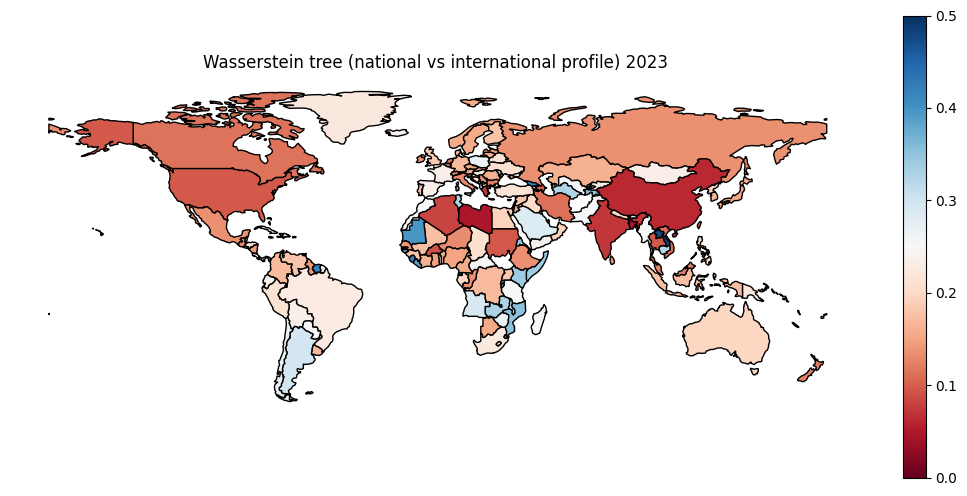

In [317]:
_, _ = uf.plot_map_continuous(df_stats, "w1_tree", title=f"Wasserstein tree (national vs international profile) {year}", range=(0, 0.5))

In [318]:
# px.histogram(df_stats, x="w1_tree", nbins=50)

# Cosine

In [202]:
df_global = pd.read_csv(uf.PATH+"df_stats_subfields_global_yearly.csv").query("year == @year")
df_global.subfield_id = df_global.subfield_id.astype(int)
df_global = (
    df_global
    .set_index("subfield_id")
    .assign(
        z_score_individual=lambda df: (df.counts_individual - df.counts_individual.mean()) / df.counts_individual.std(),
        z_score_collab=lambda df: (df.counts_collab - df.counts_collab.mean()) / df.counts_collab.std(),
    )
)


In [319]:
df_im_collab = np.log(df_prob_collab.div(df_global["probability_collab"].values, axis="columns"))
df_im_indiv = np.log(df_prob_indiv.div(df_global["probability_individual"].values, axis="columns"))

In [375]:
for c in df_stats.index:
    if (c in df_cs_collab.index) and (c in df_cs_indiv.index):
        # print(c)
        # df_stats.loc[c, "cosine_0"] = min(spd.cosine(df_im_collab.loc[c].fillna(0), df_im_indiv.loc[c].fillna(0)), 1)
        df_stats.loc[c, "cosine_prob"] = min(spd.cosine(df_prob_collab.loc[c].fillna(0), df_prob_indiv.loc[c].fillna(0)), 1)
        if c not in df_cs_collab_roll.index:
            continue
        df_stats_roll.loc[c, "cosine_prob"] = min(spd.cosine(df_prob_collab_roll.loc[c].fillna(0), df_prob_indiv_roll.loc[c].fillna(0)), 1)
    else:
        df_stats.loc[c, "cosine_0"] = np.nan
        df_stats.loc[c, "cosine_prob"] = np.nan

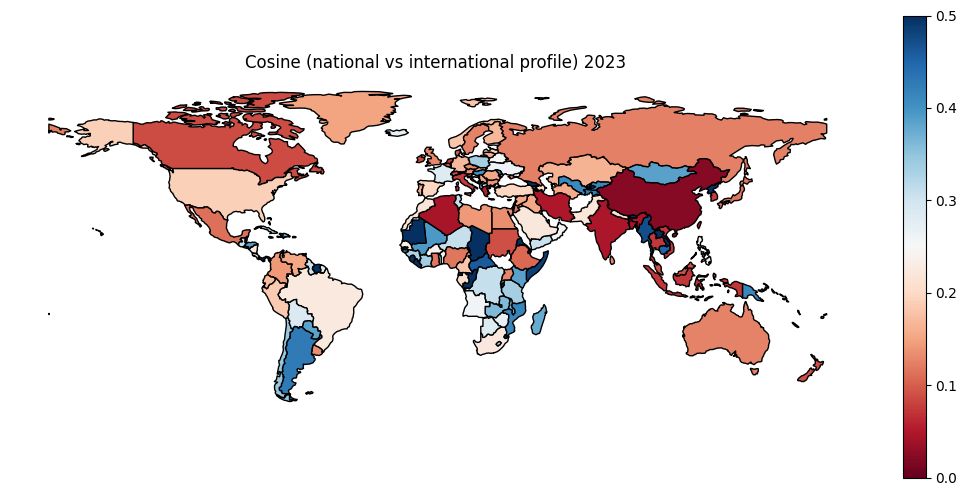

In [353]:
_, _ = uf.plot_map_continuous(df_stats, "cosine_prob", title=f"Cosine (national vs international profile) {year}", range=(0, 0.5))

In [322]:
df_country_stats

,mode,year,entropy,norm_entropy,total_articles,log_total_articles,gini
country,,,,,,,
AE,individual,1970,2.740875,0.496045,34.0,3.526361,0.323529
AF,individual,1970,1.609438,0.291277,5.0,1.609438,0.000000
AM,individual,1970,3.126757,0.565882,65.0,4.174387,0.383333
AO,individual,1970,0.693147,0.125446,2.0,0.693147,0.000000
AR,individual,1970,4.278805,0.774381,873.0,6.771936,0.600798
...,...,...,...,...,...,...,...
WS,collaborative,2022,2.770960,0.501129,44.0,3.784190,0.371901
YE,collaborative,2022,4.587269,0.829610,1165.0,7.060476,0.560279
ZA,collaborative,2022,4.710430,0.851884,12326.0,9.419466,0.636341


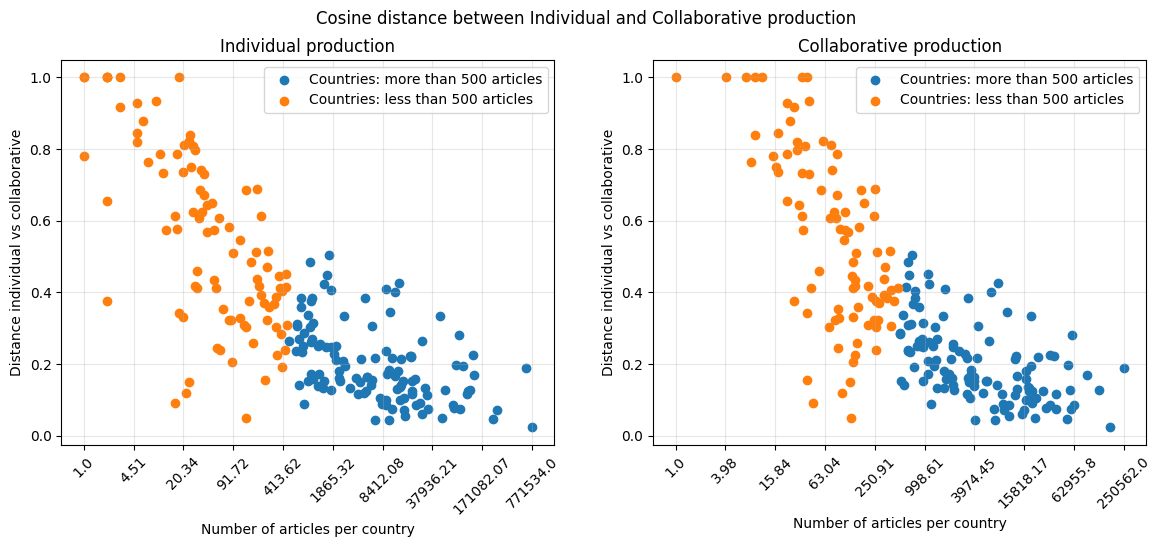

In [323]:
fig, (ax1, ax2) = plt.subplots(nrows = 1, ncols=2, figsize=(14, 5))

ax1.scatter(df_stats.query("total_indiv >= @cap_articles").log_total_indiv, df_stats.query("total_indiv >= @cap_articles").cosine_prob, label=f"Countries: more than {cap_articles} articles")
ax1.scatter(df_stats.query("total_indiv < @cap_articles").log_total_indiv, df_stats.query("total_indiv < @cap_articles").cosine_prob, label=f"Countries: less than {cap_articles} articles")

ax1.legend()

ticks = np.linspace(0, df_stats.log_total_indiv.max(), 10)
ax1.set_xticks(ticks)
ax1.set_xticklabels(np.round(np.exp(ticks), 2))
ax1.tick_params(axis='x', rotation=45)
ax1.set_xlabel("Number of articles per country")
ax1.set_ylabel("Distance individual vs collaborative")
ax1.set_title("Individual production")

ax1.grid(alpha=0.3)

ax2.scatter(df_stats.query("total_collab >= @cap_articles").log_total_collab, df_stats.query("total_collab >= @cap_articles").cosine_prob, label=f"Countries: more than {cap_articles} articles")
ax2.scatter(df_stats.query("total_collab < @cap_articles").log_total_collab, df_stats.query("total_collab < @cap_articles").cosine_prob, label=f"Countries: less than {cap_articles} articles")
ax2.grid(alpha=0.3)

ax2.legend()

ticks = np.linspace(0, df_stats.log_total_collab.max(), 10)
ax2.set_xticks(ticks)
ax2.set_xticklabels(np.round(np.exp(ticks), 2))
ax2.tick_params(axis='x', rotation=45)
ax2.set_xlabel("Number of articles per country")
ax2.set_ylabel("Distance individual vs collaborative")
ax2.set_title("Collaborative production")

_ = plt.suptitle("Cosine distance between Individual and Collaborative production")

# Compare boxplots

In [376]:
metrics = ["w1_tree", "cosine_prob"]

In [377]:
df_stats

,alpha-3,name,sub-region,region,total_indiv,total_collab,log_total_indiv,log_total_collab,gini_indiv,gini_collab,w1_tree,w1_tree_capped,cosine_prob,cosine_0
country,,,,,,,,,,,,,,
AD,AND,Andorra,Southern Europe,Europe,8.0,26.0,2.079442,3.258097,0.166667,0.256410,0.246015,NaN,0.961424,NaN
AE,ARE,United Arab Emirates,Western Asia,Asia,5170.0,9863.0,8.550628,9.196546,0.626830,0.662031,0.090023,NaN,0.080422,NaN
AF,AFG,Afghanistan,Southern Asia,Asia,529.0,400.0,6.270988,5.991465,0.593240,0.477792,0.254948,NaN,0.371583,NaN
AG,ATG,Antigua and Barbuda,Latin America and the Caribbean,Americas,115.0,370.0,4.744932,5.913503,0.382609,0.525070,0.060591,NaN,0.148715,NaN
AL,ALB,Albania,Southern Europe,Europe,969.0,425.0,6.876265,6.052089,0.579670,0.449356,0.317118,NaN,0.375022,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
WS,WSM,Samoa,Polynesia,Oceania,12.0,34.0,2.484907,3.526361,0.203704,0.294118,0.320659,NaN,0.575000,NaN
YE,YEM,Yemen,Western Asia,Asia,949.0,1318.0,6.855409,7.183871,0.543132,0.561695,0.237864,NaN,0.304852,NaN
ZA,ZAF,South Africa,Sub-Saharan Africa,Africa,19694.0,12556.0,9.888069,9.437954,0.646743,0.631085,0.225471,NaN,0.222852,NaN


In [378]:
df_stats.query("total_indiv >= @cap_articles")[metrics].corr()

,w1_tree,cosine_prob
w1_tree,1.000000,0.814804
cosine_prob,0.814804,1.000000


In [379]:
df_stats.query("total_indiv >= @cap_articles")[["total_indiv", "total_collab", "log_total_indiv", "log_total_collab", "gini_indiv", "gini_collab"]+metrics].corr()

,total_indiv,total_collab,log_total_indiv,log_total_collab,gini_indiv,gini_collab,w1_tree,cosine_prob
total_indiv,1.000000,0.868094,0.616619,0.535096,0.341224,0.315181,-0.247386,-0.234454
total_collab,0.868094,1.000000,0.670268,0.692102,0.221340,0.351468,-0.234390,-0.255330
log_total_indiv,0.616619,0.670268,1.000000,0.927310,0.581685,0.663694,-0.265775,-0.470300
log_total_collab,0.535096,0.692102,0.927310,1.000000,0.406145,0.757583,-0.312661,-0.552064
gini_indiv,0.341224,0.221340,0.581685,0.406145,1.000000,0.484724,0.092057,-0.128269
gini_collab,0.315181,0.351468,0.663694,0.757583,0.484724,1.000000,-0.227739,-0.520613
w1_tree,-0.247386,-0.234390,-0.265775,-0.312661,0.092057,-0.227739,1.000000,0.814804
cosine_prob,-0.234454,-0.255330,-0.470300,-0.552064,-0.128269,-0.520613,0.814804,1.000000


In [380]:
df_box = (
    df_stats
    .reset_index()
    .melt(id_vars=["country", "alpha-3", "name", "region"], var_name="metric", value_vars=metrics, value_name="value")
)

px.box(
    df_box,
    x="metric",
    y="value",
    points="all",
    hover_data=["country", "name", "region"],
    title="Dissimilarity measurement comparison: 0 -- the same, 1 -- distant",
    color="metric"
)

In [381]:
df_stats.query("total_indiv >= @cap_articles")

,alpha-3,name,sub-region,region,total_indiv,total_collab,log_total_indiv,log_total_collab,gini_indiv,gini_collab,w1_tree,w1_tree_capped,cosine_prob,cosine_0
country,,,,,,,,,,,,,,
AE,ARE,United Arab Emirates,Western Asia,Asia,5170.0,9863.0,8.550628,9.196546,0.626830,0.662031,0.090023,NaN,0.080422,NaN
AF,AFG,Afghanistan,Southern Asia,Asia,529.0,400.0,6.270988,5.991465,0.593240,0.477792,0.254948,NaN,0.371583,NaN
AL,ALB,Albania,Southern Europe,Europe,969.0,425.0,6.876265,6.052089,0.579670,0.449356,0.317118,NaN,0.375022,NaN
AM,ARM,Armenia,Western Asia,Asia,1561.0,654.0,7.353082,6.483107,0.620867,0.508295,0.300595,NaN,0.447515,NaN
AR,ARG,Argentina,Latin America and the Caribbean,Americas,13647.0,7561.0,9.521275,8.930759,0.650537,0.630816,0.296569,NaN,0.426255,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
VN,VNM,Viet Nam,South-eastern Asia,Asia,11313.0,6850.0,9.333708,8.832004,0.661789,0.641198,0.113150,NaN,0.073506,NaN
YE,YEM,Yemen,Western Asia,Asia,949.0,1318.0,6.855409,7.183871,0.543132,0.561695,0.237864,NaN,0.304852,NaN
ZA,ZAF,South Africa,Sub-Saharan Africa,Africa,19694.0,12556.0,9.888069,9.437954,0.646743,0.631085,0.225471,NaN,0.222852,NaN


In [382]:
metric = ["w1_tree", "cosine_prob"]
px.bar(df_stats.query("total_indiv >= @cap_articles").sort_values(metric).reset_index(), x="alpha-3", y=metric, hover_data=["country", "alpha-3", "name", "region"], barmode="group")

In [ ]:
df_subfield = uf.df_topics[["subfield_id", "field_id", "domain_id"]].drop_duplicates().sort_values(["domain_id", "field_id", "subfield_id"])
sf_ordered = df_subfield.subfield_id.astype(str).to_list()
domain_list = df_subfield.domain_id.drop_duplicates().to_list()
field_list = df_subfield.field_id.drop_duplicates().to_list()

In [407]:
country = "CN"
df_stats.loc[country]

alpha-3                      CHN
name                       China
sub-region          Eastern Asia
region                      Asia
total_indiv             771534.0
total_collab            172220.0
log_total_indiv        13.556136
log_total_collab       12.056528
gini_indiv              0.706139
gini_collab              0.69752
w1_tree                 0.061143
w1_tree_capped               NaN
cosine_prob             0.023191
cosine_0                     NaN
Name: CN, dtype: object

In [408]:
spd.cosine(df_prob_indiv.loc[country].fillna(0), df_prob_collab.loc[country].fillna(0))

np.float64(0.023191146240972405)

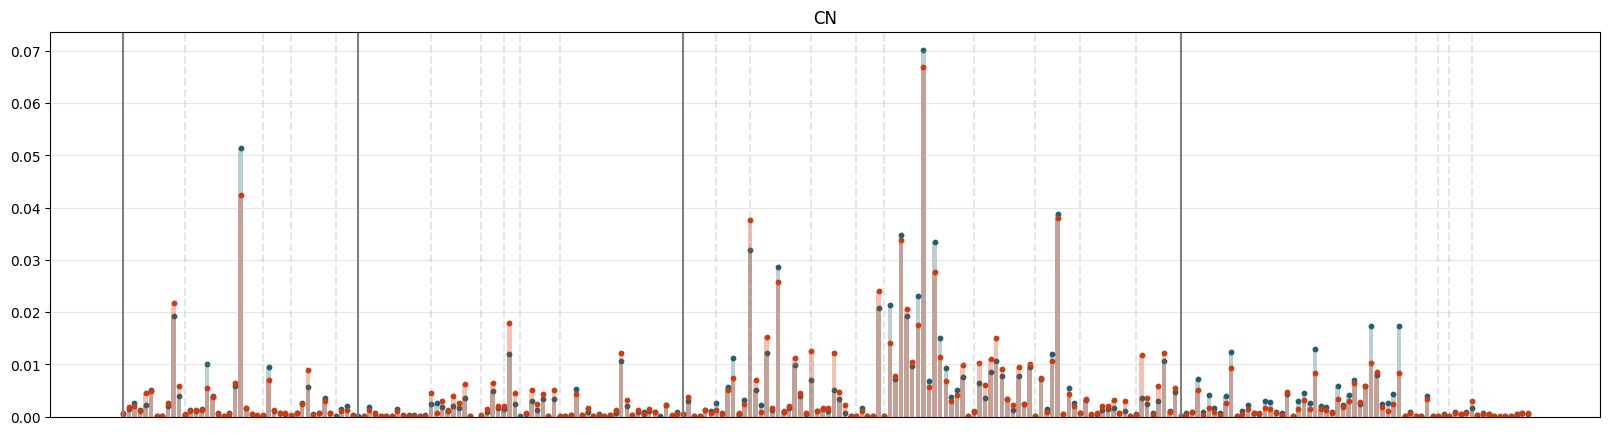

In [409]:
fig, ax = plt.subplots(figsize = (20, 5))
ax.bar(df_prob_indiv[sf_ordered].loc[country].index.astype(str), df_prob_indiv[sf_ordered].loc[country].values, color="#1F6173", alpha=0.3)
ax.scatter(df_prob_indiv[sf_ordered].loc[country].index.astype(str), df_prob_indiv[sf_ordered].loc[country].values, s=10, color="#1F6173")

ax.bar(df_prob_collab[sf_ordered].loc[country].index.astype(str), df_prob_collab[sf_ordered].loc[country].values, color="#D8370A", alpha=0.3)
ax.scatter(df_prob_collab[sf_ordered].loc[country].index.astype(str), df_prob_collab[sf_ordered].loc[country].values, s=10, color="#D8370A")

for domain in domain_list:
    start_domain = df_subfield.query("domain_id == @domain").subfield_id.iloc[0].astype(str)
    ax.axvline(start_domain, color="grey")

for field in field_list:
    start_domain = df_subfield.query("field_id == @field").subfield_id.iloc[0].astype(str)
    ax.axvline(start_domain, color="grey", linestyle="--", alpha=0.2)

# ax.axvline("1110", color="red")

ax.grid(axis="y", alpha=0.3)
# ax.set_ylim(0, 0.05)
_ = ax.set_xticks([],labels=[])
_ = ax.set_title(country)

# fig.savefig(
#     "profiles.svg",
#     format="svg",
#     transparent=True,
#     bbox_inches="tight"
# )

In [388]:
# country = "US"
df_stats_roll.loc[country]

alpha-3                                  USA
name                United States of America
sub-region                  Northern America
region                              Americas
total_indiv                         702393.0
total_collab                        275161.0
log_total_indiv                    13.462248
log_total_collab                   12.525112
gini_indiv                          0.644493
gini_collab                         0.631243
w1_tree                             0.098128
cosine_prob                         0.175537
Name: US, dtype: object

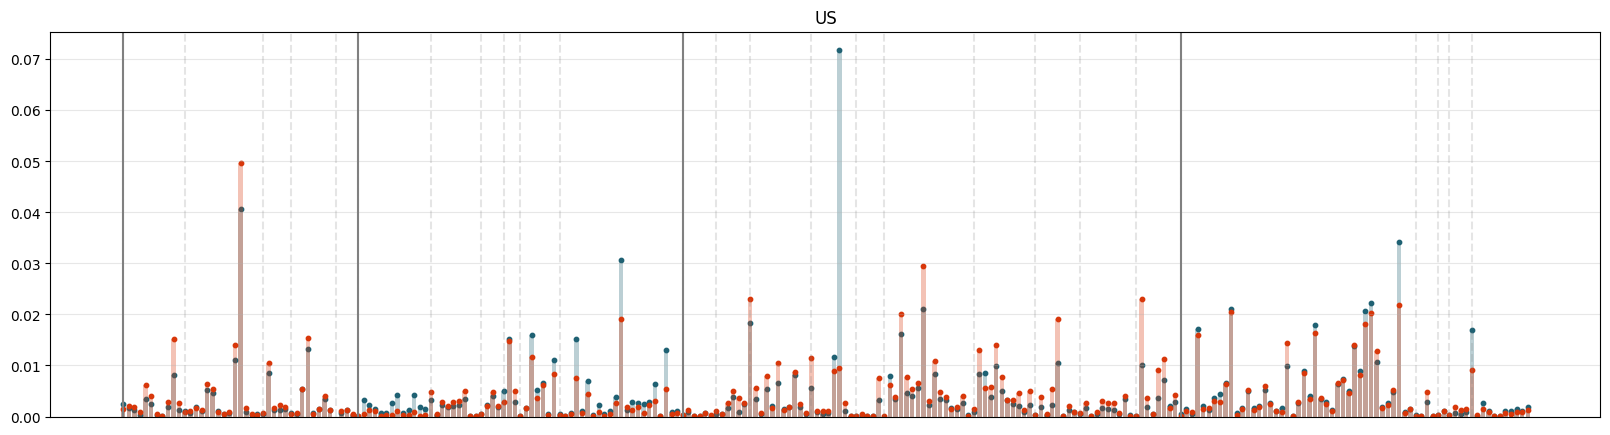

In [389]:
fig, ax = plt.subplots(figsize = (20, 5))
ax.bar(df_prob_indiv_roll[sf_ordered].loc[country].index.astype(str), df_prob_indiv_roll[sf_ordered].loc[country].values, color="#1F6173", alpha=0.3)
ax.scatter(df_prob_indiv_roll[sf_ordered].loc[country].index.astype(str), df_prob_indiv_roll[sf_ordered].loc[country].values, s=10, color="#1F6173")

ax.bar(df_prob_collab_roll[sf_ordered].loc[country].index.astype(str), df_prob_collab_roll[sf_ordered].loc[country].values, color="#D8370A", alpha=0.3)
ax.scatter(df_prob_collab_roll[sf_ordered].loc[country].index.astype(str), df_prob_collab_roll[sf_ordered].loc[country].values, s=10, color="#D8370A")

for domain in domain_list:
    start_domain = df_subfield.query("domain_id == @domain").subfield_id.iloc[0].astype(str)
    ax.axvline(start_domain, color="grey")

for field in field_list:
    start_domain = df_subfield.query("field_id == @field").subfield_id.iloc[0].astype(str)
    ax.axvline(start_domain, color="grey", linestyle="--", alpha=0.2)

# ax.axvline("1110", color="red")

ax.grid(axis="y", alpha=0.3)
# ax.set_ylim(0, 0.05)
_ = ax.set_xticks([],labels=[])
_ = ax.set_title(country)

# fig.savefig(
#     "profiles.svg",
#     format="svg",
#     transparent=True,
#     bbox_inches="tight"
# )

In [340]:
country = "PG"
df_profile_country = pd.concat([
    df_prob_indiv_roll.loc[country].to_frame("indiv"), df_prob_collab_roll.loc[country].to_frame("collab")
]).loc[sf_ordered]
px.bar(df_profile_country, x=df_profile_country.index, y=["indiv", "collab"], barmode="overlay", title=country)

# Compare global

In [124]:
subfield_tree = uf.get_subfield_tree(uf.df_topics)

df_global = pd.read_csv(uf.PATH+"df_stats_subfields_global_yearly.csv").query("year == @year")
df_global.subfield_id = df_global.subfield_id.astype(int)
df_global = (
    df_global
    .set_index("subfield_id")
    .assign(
        z_score_individual=lambda df: (df.counts_individual - df.counts_individual.mean()) / df.counts_individual.std(),
        z_score_collab=lambda df: (df.counts_collab - df.counts_collab.mean()) / df.counts_collab.std(),
    )
)

In [48]:
_, _, _ = uf.get_dist_w1_tree(subfield_tree,
                    df_global.reset_index("subfield_id").assign(subfield_str=lambda df: df.subfield_id.astype(str)).set_index("subfield_str").probability_individual.dropna().to_dict(),
                    df_global.reset_index("subfield_id").assign(subfield_str=lambda df: df.subfield_id.astype(str)).set_index("subfield_str").probability_collab.dropna().to_dict())

In [49]:
# px.bar(df_global, x=df_global.index.astype(str), y=["probability_individual", "probability_collab"], barmode="overlay")

# Compare local to global

In [50]:
global_dict_indiv = (
    df_global
    .reset_index("subfield_id")
    .assign(subfield_str=lambda df: df.subfield_id.astype(str))
    .set_index("subfield_str")
    .probability_individual
    .dropna()
    .to_dict()
)
global_dict_collab = (
    df_global
    .reset_index("subfield_id")
    .assign(subfield_str=lambda df: df.subfield_id.astype(str))
    .set_index("subfield_str")
    .probability_collab
    .dropna()
    .to_dict()
)

In [51]:
importlib.reload(uf)

<module 'utility_functions' from '/Users/irinavorobeva/Documents/Sociology/Geography Topics/geoTopics/irina/utility_functions.py'>

In [52]:
# different subfield, fields, domains (maximum distance)
subfield1 = "2713"
subfield2 = "1904"
_, _, w1_max = uf.get_dist_w1_tree(subfield_tree, {subfield1: 1}, {subfield2: 1})

uf.get_jaccard(df_stats, df_cs_collab, df_global, col_name="jaccard_gl_collab", col_df2="counts_collab")
uf.get_jaccard(df_stats, df_cs_indiv, df_global, col_name="jaccard_gl_indiv", col_df2="counts_individual")

uf.get_w1_tree(df=df_stats, subfield_tree=subfield_tree, df1=df_prob_collab, dict2=global_dict_collab, col_name="w1_tree_gl_collab")
uf.get_w1_tree(df=df_stats, subfield_tree=subfield_tree, df1=df_prob_indiv, dict2=global_dict_indiv, col_name="w1_tree_gl_indiv", w1_max=w1_max)

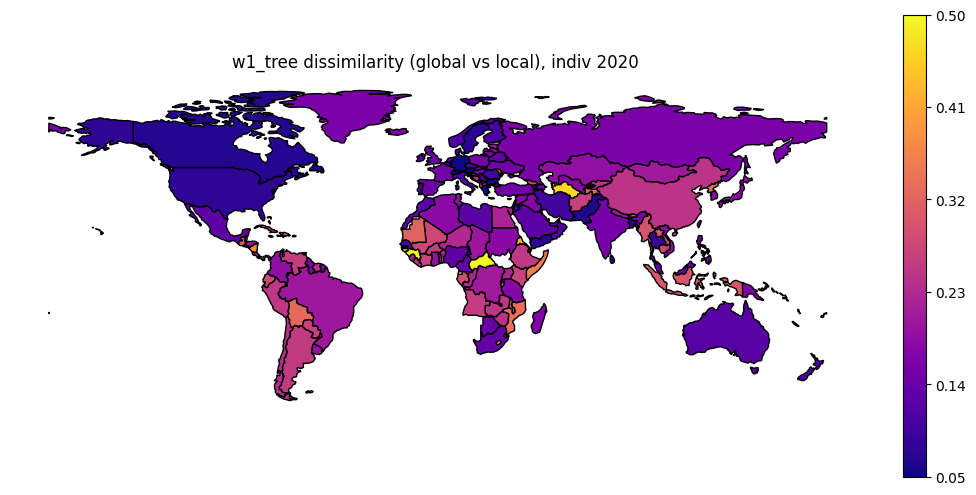

In [53]:
mode = "w1_tree"
regime = "indiv"
_, _ = uf.plot_map_continuous(df_stats, f"{mode}_gl_{regime}",
                              title=f"{mode} dissimilarity (global vs local), {regime} {year}",
                              range=(0.05, 0.5))

In [54]:
df_box_gl = (df_stats.reset_index().melt(id_vars=["country", "alpha-3", "name", "region"],
                                         var_name="metric",
                                         value_vars=["w1_tree_gl_indiv", "w1_tree_gl_collab", "jaccard_gl_collab", "jaccard_gl_indiv"], value_name="value"))

In [55]:
px.box(
    df_box_gl,
    x="metric",
    y="value",
    points="all",
    hover_data=["alpha-3", "name", "region"],
    color="metric",
    title="Dissimilarity comparison: local vs global"
)

# Pipeline yearly



In [56]:
importlib.reload(uf)

<module 'utility_functions' from '/Users/irinavorobeva/Documents/Sociology/Geography Topics/geoTopics/irina/utility_functions.py'>

In [57]:
start_year = 1970
end_year = 2023

subfield1 = "2713"
subfield2 = "1904"

subfield_tree = uf.get_subfield_tree(uf.df_topics)
_, _, w1_max = uf.get_dist_w1_tree(subfield_tree, {subfield1: 1}, {subfield2: 1})

df_stats_list = []
for year_loop in range(start_year, end_year+1):
    try:
        df_cs_indiv_loop = pd.read_csv(uf.PATH+"df_country_subfield/individual_{}.csv".format(year_loop), index_col=0)
        df_cs_collab_loop = pd.read_csv(uf.PATH+"df_country_subfield/collaborative_{}.csv".format(year_loop), index_col=0)

        all_cols = df_cs_indiv_loop.columns.union(df_cs_collab_loop.columns)

        df_cs_collab_loop = df_cs_collab_loop.reindex(columns=all_cols)
        df_cs_indiv_loop = df_cs_indiv_loop.reindex(columns=all_cols)

        df_global_loop = pd.read_csv(uf.PATH+"df_global_comparison_yearly.csv").drop_duplicates().query("year == @year_loop")
        df_global_loop.subfield_id = df_global_loop.subfield_id.astype(int)
        df_global_loop = (
            df_global_loop
            .set_index("subfield_id")
            .assign(
                z_score_individual=lambda df: (df.counts_individual - df.counts_individual.mean()) / df.counts_individual.std(),
                z_score_collab=lambda df: (df.counts_collab - df.counts_collab.mean()) / df.counts_collab.std(),
            )
        )

        global_dict_indiv_loop = (
        df_global_loop
        .reset_index("subfield_id")
        .assign(subfield_str=lambda df: df.subfield_id.astype(str))
        .set_index("subfield_str")
        .probability_individual
        .dropna()
        .to_dict()
        )
        global_dict_collab_loop = (
            df_global_loop
            .reset_index("subfield_id")
            .assign(subfield_str=lambda df: df.subfield_id.astype(str))
            .set_index("subfield_str")
            .probability_collab
            .dropna()
            .to_dict()
        )

        df_prob_collab_loop = df_cs_collab_loop.div(df_cs_collab_loop.sum(axis=1), axis=0)
        df_prob_indiv_loop = df_cs_indiv_loop.div(df_cs_indiv_loop.sum(axis=1), axis=0)

        df_stats_loop = (
            pd.DataFrame(index=(df_cs_indiv_loop.index.union(df_cs_collab_loop.index)))
            .merge(uf.df_country[["alpha-2", "alpha-3", "name", "region"]], left_index=True, right_on="alpha-2")
            .rename(columns={"alpha-2": "country"})
            .set_index("country")
            .assign(year=year_loop)
        )

        uf.get_jaccard(df_stats_loop, df_cs_collab_loop, df_cs_indiv_loop, col_name="jaccard")
        uf.get_jaccard(df_stats_loop, df_cs_collab_loop, df_global_loop, col_name="jaccard_gl_collab", col_df2="counts_collab")
        uf.get_jaccard(df_stats_loop, df_cs_indiv_loop, df_global_loop, col_name="jaccard_gl_indiv", col_df2="counts_individual")

        uf.get_w1_tree(df=df_stats_loop, subfield_tree=subfield_tree, df1=df_prob_collab_loop, df2=df_prob_indiv_loop, col_name="w1_tree", w1_max=w1_max)
        uf.get_w1_tree(df=df_stats_loop, subfield_tree=subfield_tree, df1=df_prob_collab_loop, dict2=global_dict_collab_loop, col_name="w1_tree_gl_collab", w1_max=w1_max)
        uf.get_w1_tree(df=df_stats_loop, subfield_tree=subfield_tree, df1=df_prob_indiv_loop, dict2=global_dict_indiv_loop, col_name="w1_tree_gl_indiv", w1_max=w1_max)

        df_stats_list.append(df_stats_loop)
    except Exception as e:
        print(year_loop, e)

1970 [Errno 2] No such file or directory: '../data/df_global_comparison_yearly.csv'
1971 [Errno 2] No such file or directory: '../data/df_global_comparison_yearly.csv'
1972 [Errno 2] No such file or directory: '../data/df_global_comparison_yearly.csv'
1973 [Errno 2] No such file or directory: '../data/df_global_comparison_yearly.csv'
1974 [Errno 2] No such file or directory: '../data/df_global_comparison_yearly.csv'
1975 [Errno 2] No such file or directory: '../data/df_global_comparison_yearly.csv'
1976 [Errno 2] No such file or directory: '../data/df_global_comparison_yearly.csv'
1977 [Errno 2] No such file or directory: '../data/df_global_comparison_yearly.csv'
1978 [Errno 2] No such file or directory: '../data/df_global_comparison_yearly.csv'
1979 [Errno 2] No such file or directory: '../data/df_global_comparison_yearly.csv'
1980 [Errno 2] No such file or directory: '../data/df_global_comparison_yearly.csv'
1981 [Errno 2] No such file or directory: '../data/df_global_comparison_year

In [58]:
# pd.concat(df_stats_list).reset_index().to_csv(uf.PATH+"df_stats_national_international_1970_2023.csv", index=False)

In [60]:
# start_year = 1970
# end_year = 2023
# year_list = range(start_year, end_year+1)
#
# mode_list = ["individual", "collaborative"]
#
# df_prob_yearly_list = []
#
#
# for year_loop in year_list:
#     for mode_loop in mode_list:
#         df_tmp = pd.read_csv(uf.PATH+f"df_country_subfield/{mode_loop}_{year_loop}.csv", index_col=0)
#         df_prob_yearly_list.append(
#             df_tmp.div(df_tmp.sum(axis=1), axis=0).reset_index().assign(year=year_loop, mode=mode_loop)
#         )
#
# df_prob_yearly = pd.concat(df_prob_yearly_list)

In [61]:
# df_prob_yearly.to_csv(uf.PATH+f"df_prob_yearly.csv", index=False)

# Demonstration yearly

In [3]:
df_cs_yearly_full = pd.read_csv(uf.PATH+"df_cs_yearly.csv", index_col=[0, 1, 2])
df_prob_yearly_full = df_cs_yearly_full.div(df_cs_yearly_full.sum(axis=1), axis=0)

n_years = 5

df_cs_roll_yearly_full = (
    df_cs_yearly_full
    # .sort_index()
    .groupby(level=[0, 2])
    .rolling(n_years).sum()
    .reset_index(level=[0, 1], drop=True)
)
df_prob_roll_yearly_full = df_cs_roll_yearly_full.div(df_cs_roll_yearly_full.sum(axis=1), axis=0)

In [4]:
importlib.reload(uf)

<module 'utility_functions' from '/Users/irinavorobeva/Documents/Sociology/Geography Topics/geoTopics/irina/utility_functions.py'>

In [5]:
start_year = 1975
end_year = 2023

df_dist_list = []
for year_loop in range(start_year, end_year+1):
    df1 = df_prob_roll_yearly_full.xs((year_loop, "individual"), level=[1, 2]).dropna(how="all", axis=1)
    df2 = df_prob_roll_yearly_full.xs((year_loop, "collaborative"), level=[1, 2]).dropna(how="all", axis=1)

    df_dist_tmp = uf.get_w1_distances_matrix(df1, df2)
    c_list = list(set(df_dist_tmp.index) & set(df_dist_tmp.columns))
    df_dist_list.append(
        pd.DataFrame(np.diagonal(df_dist_tmp.loc[c_list, c_list].values), index=c_list, columns=["dist"]).assign(year=year_loop)
    )
df_dist = pd.concat(df_dist_list)

/Users/irinavorobeva/Documents/Sociology/Geography Topics/geoTopics/irina/utility_functions.py:1246: RuntimeWarning: divide by zero encountered in matmul
  q12 = np.matmul(q11, adj_leaves)
/Users/irinavorobeva/Documents/Sociology/Geography Topics/geoTopics/irina/utility_functions.py:1246: RuntimeWarning: overflow encountered in matmul
  q12 = np.matmul(q11, adj_leaves)
/Users/irinavorobeva/Documents/Sociology/Geography Topics/geoTopics/irina/utility_functions.py:1246: RuntimeWarning: invalid value encountered in matmul
  q12 = np.matmul(q11, adj_leaves)
/Users/irinavorobeva/Documents/Sociology/Geography Topics/geoTopics/irina/utility_functions.py:1375: RuntimeWarning: divide by zero encountered in matmul
  np.sum(np.abs(wass_array_short @ df_diff.fillna(0).values.T), axis=0),
/Users/irinavorobeva/Documents/Sociology/Geography Topics/geoTopics/irina/utility_functions.py:1375: RuntimeWarning: overflow encountered in matmul
  np.sum(np.abs(wass_array_short @ df_diff.fillna(0).values.T), a

In [6]:
df_map = pd.read_csv(uf.PATH+"df_map_analysis_01.csv")

In [7]:
df_stats_dyn = (
    df_dist.reset_index(names="country")
    .merge(df_map, on=["country", "year"], how="right")
)

In [12]:
country_list = ["US", "FR", "CN", "CH", "IN", "ID", "AU", "BR", "RU", "FI"]

In [13]:
df_stats_dyn

,country,dist,year,cluster
0,AR,0.388160,1975,8.0
1,AT,0.316043,1975,0.0
2,AU,0.125573,1975,7.0
3,BE,0.227157,1975,5.0
4,BG,0.126119,1975,4.0
...,...,...,...,...
3853,VN,0.131762,2023,12.0
3854,YE,0.233069,2023,5.0
3855,ZA,0.220741,2023,12.0
3856,ZM,0.378581,2023,10.0


In [14]:
# fig = px.box(
#     (
#         df_stats_dyn
#         .query("country in @country_list")
#         # .query("year > @test_year")
#     ),
#     x="year",
#     y="jaccard",
#     points="outliers",
#     hover_data=["country"],
#     title="Jaccard dissimilarity between national and international profiles"
#     # color="region"
# )
# fig.update_traces(
#     marker=dict(color="grey"),
#     line=dict(color="grey"),
#     opacity=0.5
# )
# for country in country_list:
#     fig.add_scatter(
#         x=df_stats_dyn.query("country == @country").year,
#         y=df_stats_dyn.query("country == @country").jaccard,
#         mode="lines",
#         name=country,
#         # line=dict(width=3)
#     )
# fig.show()
# # fig.write_image("../images/w1_tree_box_1970_2023.png",
# #                 width=1200, height=600, scale=2)

In [17]:
uf.df_country[uf.df_country["alpha-2"] == "FI"]

,name,alpha-2,alpha-3,country-code,iso_3166-2,region,sub-region,intermediate-region,region-code,sub-region-code,intermediate-region-code
75,Finland,FI,FIN,246,ISO 3166-2:FI,Europe,Northern Europe,NaN,150.0,154.0,NaN


NameError: name 'df_prob' is not defined

In [15]:
fig = px.box(
    (
        df_stats_dyn
        # .query("year > @test_year")
        # .query("country in @countries")
    ),
    x="year",
    y="dist",
    points="outliers",
    hover_data=["country"],
    title="W1-tree Distance between national and international profiles",

    # color="grey"
)
fig.update_traces(
    marker=dict(color="grey"),
    line=dict(color="grey"),
    opacity=0.7
)
for country in country_list:
    fig.add_scatter(
        x=df_stats_dyn.query("country == @country").year,
        y=df_stats_dyn.query("country == @country").dist,
        mode="lines",
        name=country,
        # line=dict(width=3)
    )
fig.show()
# fig.write_image("../images/w1_tree_box_1970_2023.png",
#                 width=1200, height=600, scale=2)

In [12]:
year_list = df_stats_dyn.year.drop_duplicates().sort_values().to_list()

In [13]:
y = df_stats_dyn.groupby("year").dist.median().values

In [14]:
y2 = df_stats_dyn.groupby("year").dist.quantile(0.05).values
y3 = df_stats_dyn.groupby("year").dist.quantile(0.95).values

In [15]:
uf.df_country.tail(30)

,name,alpha-2,alpha-3,country-code,iso_3166-2,region,sub-region,intermediate-region,region-code,sub-region-code,intermediate-region-code
219,"Tanzania, United Republic of",TZ,TZA,834,ISO 3166-2:TZ,Africa,Sub-Saharan Africa,Eastern Africa,2.0,202.0,14.0
220,Thailand,TH,THA,764,ISO 3166-2:TH,Asia,South-eastern Asia,NaN,142.0,35.0,NaN
221,Timor-Leste,TL,TLS,626,ISO 3166-2:TL,Asia,South-eastern Asia,NaN,142.0,35.0,NaN
222,Togo,TG,TGO,768,ISO 3166-2:TG,Africa,Sub-Saharan Africa,Western Africa,2.0,202.0,11.0
223,Tokelau,TK,TKL,772,ISO 3166-2:TK,Oceania,Polynesia,NaN,9.0,61.0,NaN
224,Tonga,TO,TON,776,ISO 3166-2:TO,Oceania,Polynesia,NaN,9.0,61.0,NaN
225,Trinidad and Tobago,TT,TTO,780,ISO 3166-2:TT,Americas,Latin America and the Caribbean,Caribbean,19.0,419.0,29.0
226,Tunisia,TN,TUN,788,ISO 3166-2:TN,Africa,Northern Africa,NaN,2.0,15.0,NaN
227,Türkiye,TR,TUR,792,ISO 3166-2:TR,Asia,Western Asia,NaN,142.0,145.0,NaN
228,Turkmenistan,TM,TKM,795,ISO 3166-2:TM,Asia,Central Asia,NaN,142.0,143.0,NaN


(0.0, 1.0)

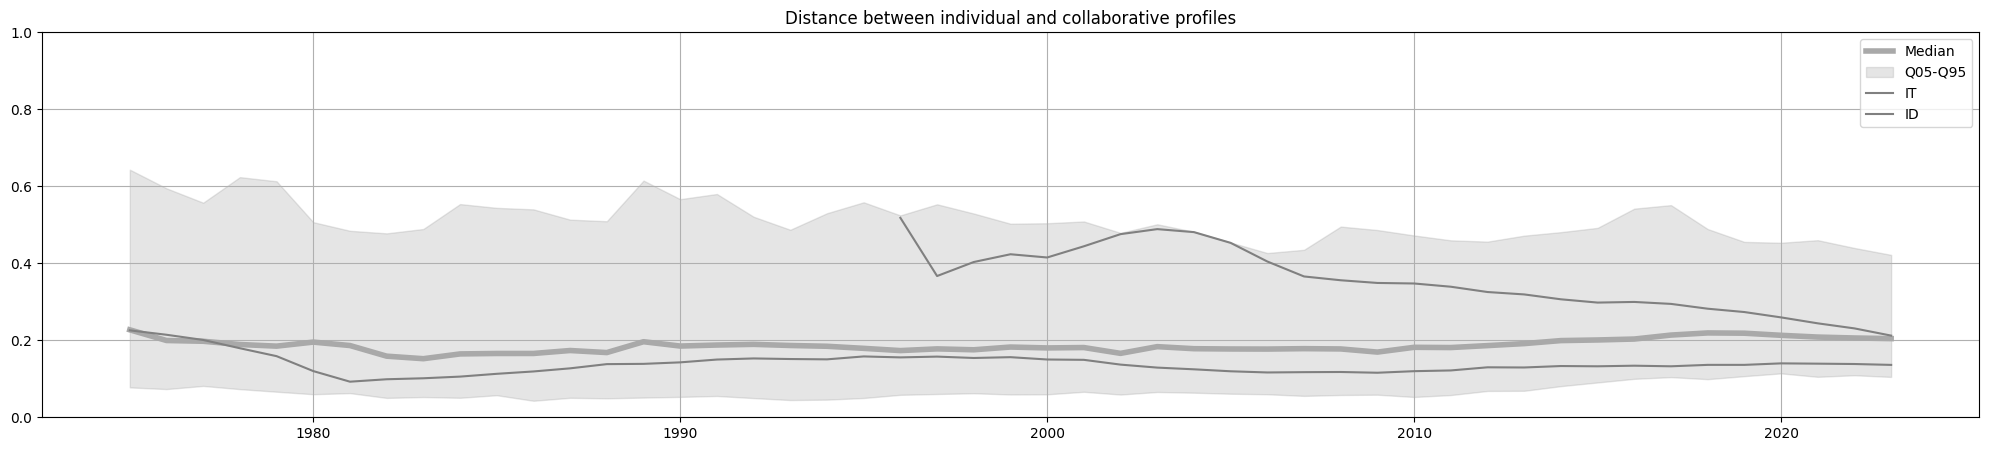

In [16]:
country_list = ["US", "FR", "CN", "IT", "IN", "ID", "AU", "BR", "RU", "IR"]
country_list = ["IT", "ID"]

plt.subplots(figsize=(25, 5))
plt.plot(year_list, y, color="darkgrey", label="Median", linewidth=4)
# plt.plot(year_list, y2)
# plt.plot(year_list, y3)
plt.fill_between(
    year_list,
    y2,
    y3,
    color='grey',
    alpha=0.2,
    label="Q05-Q95"
)

for country in country_list:
    plt.plot(year_list, df_stats_dyn.query("country == @country").set_index("year").reindex(year_list).dist, label=country, color="grey")
plt.legend()
plt.grid()
plt.title("Distance between individual and collaborative profiles")
plt.ylim(0, 1)

In [17]:
df_stats_dyn

,country,dist,year,cluster
0,AR,0.388160,1975,8.0
1,AT,0.316043,1975,0.0
2,AU,0.125573,1975,7.0
3,BE,0.227157,1975,5.0
4,BG,0.126119,1975,4.0
...,...,...,...,...
3853,VN,0.131762,2023,12.0
3854,YE,0.233069,2023,5.0
3855,ZA,0.220741,2023,12.0
3856,ZM,0.378581,2023,10.0


In [18]:
import geopandas as gpd

url = "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"
world = gpd.read_file(url)

In [19]:
df_stats_dyn

,country,dist,year,cluster
0,AR,0.388160,1975,8.0
1,AT,0.316043,1975,0.0
2,AU,0.125573,1975,7.0
3,BE,0.227157,1975,5.0
4,BG,0.126119,1975,4.0
...,...,...,...,...
3853,VN,0.131762,2023,12.0
3854,YE,0.233069,2023,5.0
3855,ZA,0.220741,2023,12.0
3856,ZM,0.378581,2023,10.0


In [20]:
year = 2023

df_share = df_cs_roll_yearly_full.sum(axis=1).to_frame("total").xs((year, "collaborative"), level=[1, 2]).dropna(how="all", axis=1) / (
    df_cs_roll_yearly_full.sum(axis=1).to_frame("total").xs((year, "individual"), level=[1, 2]).dropna(how="all", axis=1) +
    df_cs_roll_yearly_full.sum(axis=1).to_frame("total").xs((year, "collaborative"), level=[1, 2]).dropna(how="all", axis=1)
)

df_plot = (
    df_stats_dyn
    .query("year == @year")
    .drop(columns=["year", "cluster"])
    .merge(uf.df_country[["alpha-2", "alpha-3"]], left_on="country", right_on="alpha-2", how="left")
    .merge(df_share, on="country")
)

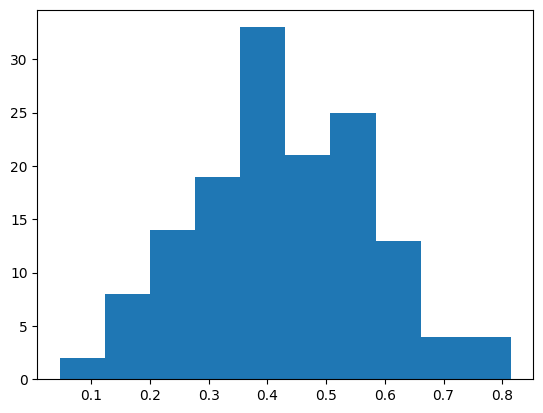

In [21]:
_ = plt.hist(df_plot.total)

In [22]:
# Merge on ISO-3 codes
gdf = world.merge(df_plot, left_on='ISO_A3_EH', right_on='alpha-3')

gdf = gdf.to_crs(epsg=3857)
gdf['centroid'] = gdf.geometry.centroid

In [23]:
c1 = "RU"
gdf.query("country == @c1")[["country", "total", "dist"]]

,country,total,dist
13,RU,0.154416,0.148457


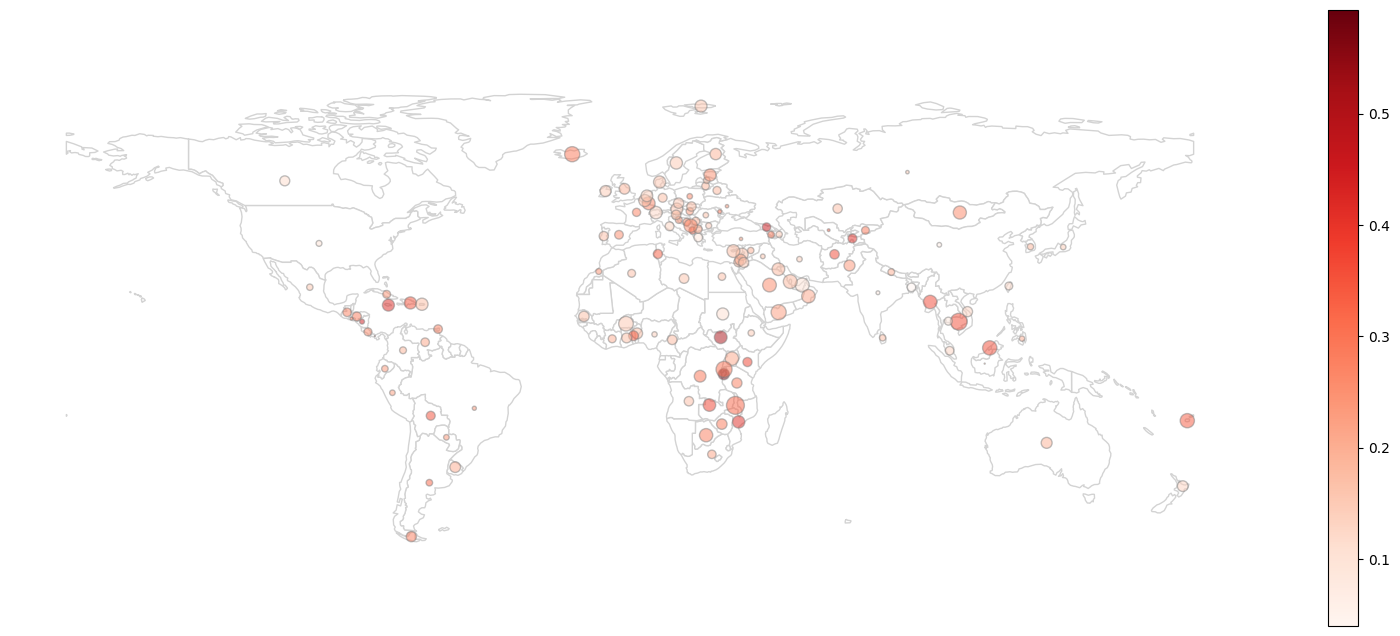

In [26]:

import matplotlib.pyplot as plt
world = world[world['CONTINENT'] != 'Antarctica']

# Merge
gdf = world.merge(df_plot, left_on='ISO_A3_EH', right_on='alpha-3')

# Convert BOTH to same CRS
world = world.to_crs(epsg=4326)
gdf = gdf.to_crs(epsg=4326)

# Compute centroids AFTER projection
gdf['point'] = gdf.geometry.representative_point()

# Plot
fig, ax = plt.subplots(figsize=(20, 8))

world.plot(ax=ax, color='white', edgecolor='lightgrey')

# plt.scatter(0, 0, s=(0.5 ** 2) * 250, edgecolor="grey", color="none")
# plt.scatter(0, 10, s=(1 ** 2) * 250, edgecolor="grey", color="none")
# plt.scatter(0, 20, s=(0.2 ** 2) * 250, edgecolor="grey", color="none")

gdf.set_geometry('point').plot(
    ax=ax,
    markersize=(gdf['total'] ** 2) * 250,
    column='dist',              # 👈 color driven by dist
    cmap='Reds',             # choose colormap
    edgecolor='grey',
    alpha=0.5,
    legend=True                 # 👈 adds colorbar
)
ax.axis('off')

fig.savefig(
    "map.svg",
    format="svg",
    transparent=True,
    bbox_inches="tight"
)
# plt.show()

# Details examples

In [22]:
country = "US" # small Jaccard, small W1
# country = "TN" # small Jaccard, relatively big W1
country="MR" # big Jaccard, relatively big W1
# country = "ST" # relatively big Jaccard small W1
# country="GE" # big W1
# country = "TV" # J=1, W1=1
# country = "AW" # big Jaccard (1), big W1
year = 2023

jaccard = df_stats_dyn.set_index(["country", "year"]).loc[(country, year), "jaccard"]
w1_tree = df_stats_dyn.set_index(["country", "year"]).loc[(country, year), "w1_tree"]

df_plot = (
    df_prob_yearly
    .query(f"country == @country and year == @year")
    .drop(["year", "country"], axis=1)
    .set_index("mode")
    .T
    .assign(subfield_id=lambda df: df.index.astype(int))
    .merge(uf.df_topics[["subfield_id", "subfield_name", "field_name", "domain_name"]].drop_duplicates(), on="subfield_id", how="left")
    .sort_values(["domain_name", "field_name", "subfield_name"])
    .assign(subfield_str=lambda df: df.subfield_id.astype(str))
    [["individual", "collaborative", "subfield_str"]]
    .set_index("subfield_str")
    .T
)

plt.subplots(figsize=[15, 5])
plt.bar(df_plot.columns,
        df_plot.loc[mode_list[0]], alpha=0.7, label=f"{mode_list[0]}, Gini = {round(uf.gini(df_plot.loc[mode_list[0]]), 2)}")
plt.bar(df_plot.columns,
        df_plot.loc[mode_list[1]], alpha=0.5, label=f"{mode_list[1]}, Gini = {round(uf.gini(df_plot.loc[mode_list[1]]), 2)}")
plt.xticks(rotation=90, fontsize=4)
plt.legend()
plt.title(f"Probabilities {uf.id2name_country[country]}, {year}: Jaccard = {round(jaccard, 2)}, W1-tree = {round(w1_tree, 2)}")
plt.grid(alpha=0.3)
plt.show()

KeyError: 'jaccard'

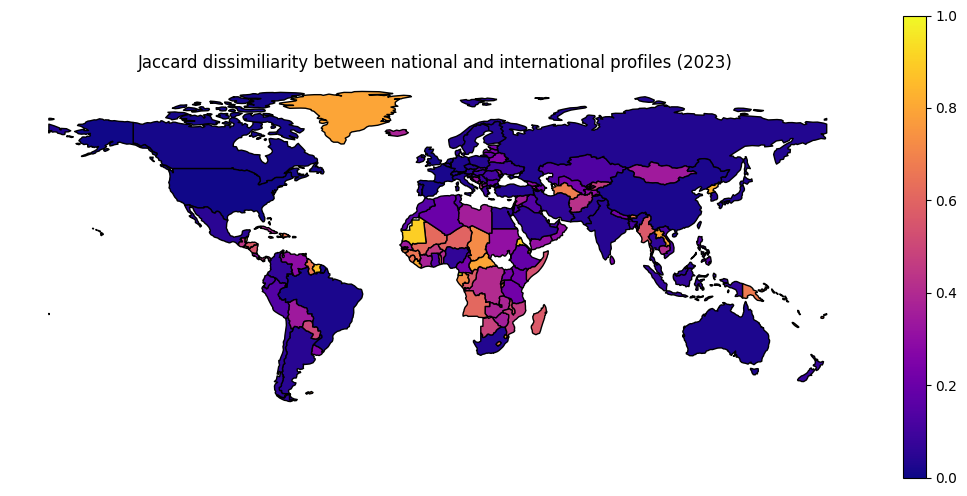

In [89]:
year = 2023
fig, ax = uf.plot_map_continuous((
    df_stats_dyn
    .query("year == @year")
), "jaccard", range = (0, 1), title=f"Jaccard dissimiliarity between national and international profiles ({year})"
)
# fig.savefig(f"../images/map_w1_tree_{year}.png")

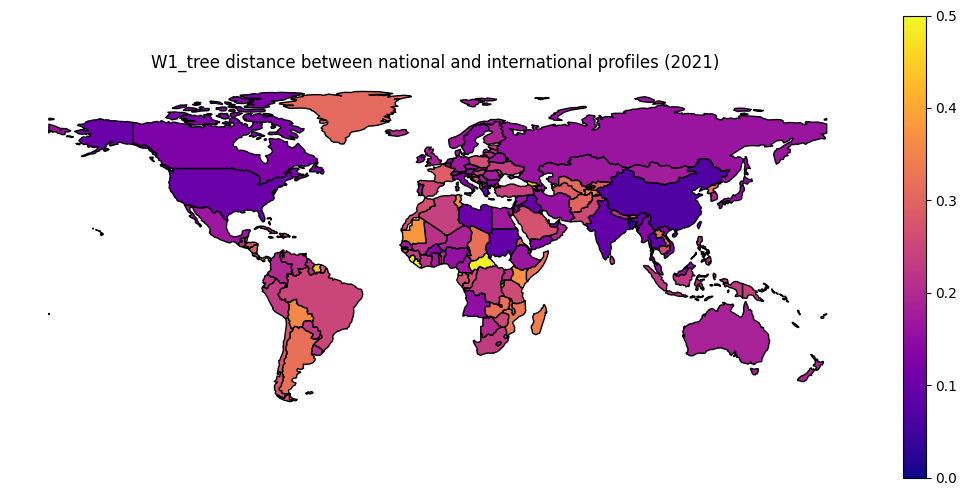

In [90]:
year = 2021
fig, ax = uf.plot_map_continuous((
    df_stats_dyn
    .query("year == @year")
), "w1_tree", range = (0, 0.5), title=f"W1_tree distance between national and international profiles ({year})"
)
# fig.savefig(f"../images/map_w1_tree_{year}.png")